# Galería

In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 300

def logistic(x):
    return 1 / (1 + np.exp(-x))

# Variables de base
edad = np.clip(rng.normal(50, 15, n), 18, 85)
sexo = rng.binomial(1, 0.50, n)       # 0 = mujer, 1 = hombre
grupo = rng.binomial(1, 0.50, n)      # 0 = control, 1 = intervención

# Gaussian GLM
imc = (
    25
    + 0.04 * (edad - 50)
    + 1.0 * sexo
    + rng.normal(0, 3, n)
)

# Gaussian GLM
presion_sistolica = (
    120
    + 0.45 * (edad - 50)
    + 1.2 * (imc - 25)
    + rng.normal(0, 10, n)
)

# Gamma GLM con link log
mu_biomarcador = np.exp(
    1.5
    + 0.015 * (edad - 50)
    + 0.04 * (imc - 25)
)
shape = 3
biomarcador = rng.gamma(shape, mu_biomarcador / shape)

# Gaussian GLM
puntaje_basal = (
    50
    + 0.15 * (edad - 50)
    + 1.5 * np.log(biomarcador)
    + rng.normal(0, 8, n)
)

# Gaussian GLM: la intervención mejora el puntaje
puntaje_final = (
    puntaje_basal
    - 6 * grupo
    + rng.normal(0, 6, n)
)

cambio_puntaje = puntaje_final - puntaje_basal

# Binomial GLM con link logit
p_respuesta = logistic(
    -0.5
    + 1.0 * grupo
    - 0.03 * (puntaje_basal - 50)
)
respuesta = rng.binomial(1, p_respuesta)

# Diagnóstico y prueba diagnóstica
p_diagnostico = logistic(
    -1
    + 0.04 * (edad - 50)
    + 0.08 * (imc - 25)
)
diagnostico = rng.binomial(1, p_diagnostico)

score_prueba = (
    40
    + 15 * diagnostico
    + 0.10 * (edad - 50)
    + rng.normal(0, 10, n)
)

# Dos métodos que miden aproximadamente lo mismo
valor_real = (
    100
    + 0.3 * (edad - 50)
    + rng.normal(0, 12, n)
)

metodo_a = valor_real + rng.normal(0, 5, n)
metodo_b = valor_real + 2 + rng.normal(0, 6, n)

df = pd.DataFrame({
    "id": np.arange(1, n + 1),
    "edad": edad,
    "sexo": np.where(sexo == 1, "Hombre", "Mujer"),
    "grupo": np.where(grupo == 1, "Intervención", "Control"),
    "imc": imc,
    "presion_sistolica": presion_sistolica,
    "biomarcador": biomarcador,
    "puntaje_basal": puntaje_basal,
    "puntaje_final": puntaje_final,
    "cambio_puntaje": cambio_puntaje,
    "respuesta": np.where(respuesta == 1, "Sí", "No"),
    "diagnostico": diagnostico,
    "score_prueba": score_prueba,
    "metodo_a": metodo_a,
    "metodo_b": metodo_b,
})

df.head()

,id,edad,sexo,grupo,imc,presion_sistolica,biomarcador,puntaje_basal,puntaje_final,cambio_puntaje,respuesta,diagnostico,score_prueba,metodo_a,metodo_b
0,1,54.570756,Mujer,Intervención,25.859510,109.883362,5.747605,61.488046,59.592273,-1.895773,Sí,0,32.272100,114.395847,116.603459
1,2,34.400238,Mujer,Intervención,27.218958,124.189715,3.692631,55.836128,46.151620,-9.684509,Sí,0,49.254529,104.116252,112.397680
2,3,61.256768,Mujer,Control,22.116956,113.603776,6.538564,53.742805,44.089965,-9.652840,No,1,52.863240,107.664490,118.438802
3,4,64.108471,Mujer,Intervención,22.048424,129.135500,7.173356,51.328020,49.339353,-1.988668,Sí,0,39.636072,106.141006,111.033638
4,5,20.734472,Mujer,Intervención,20.549407,101.383414,2.611283,42.015177,42.753745,0.738568,Sí,0,33.301518,84.291845,87.874225


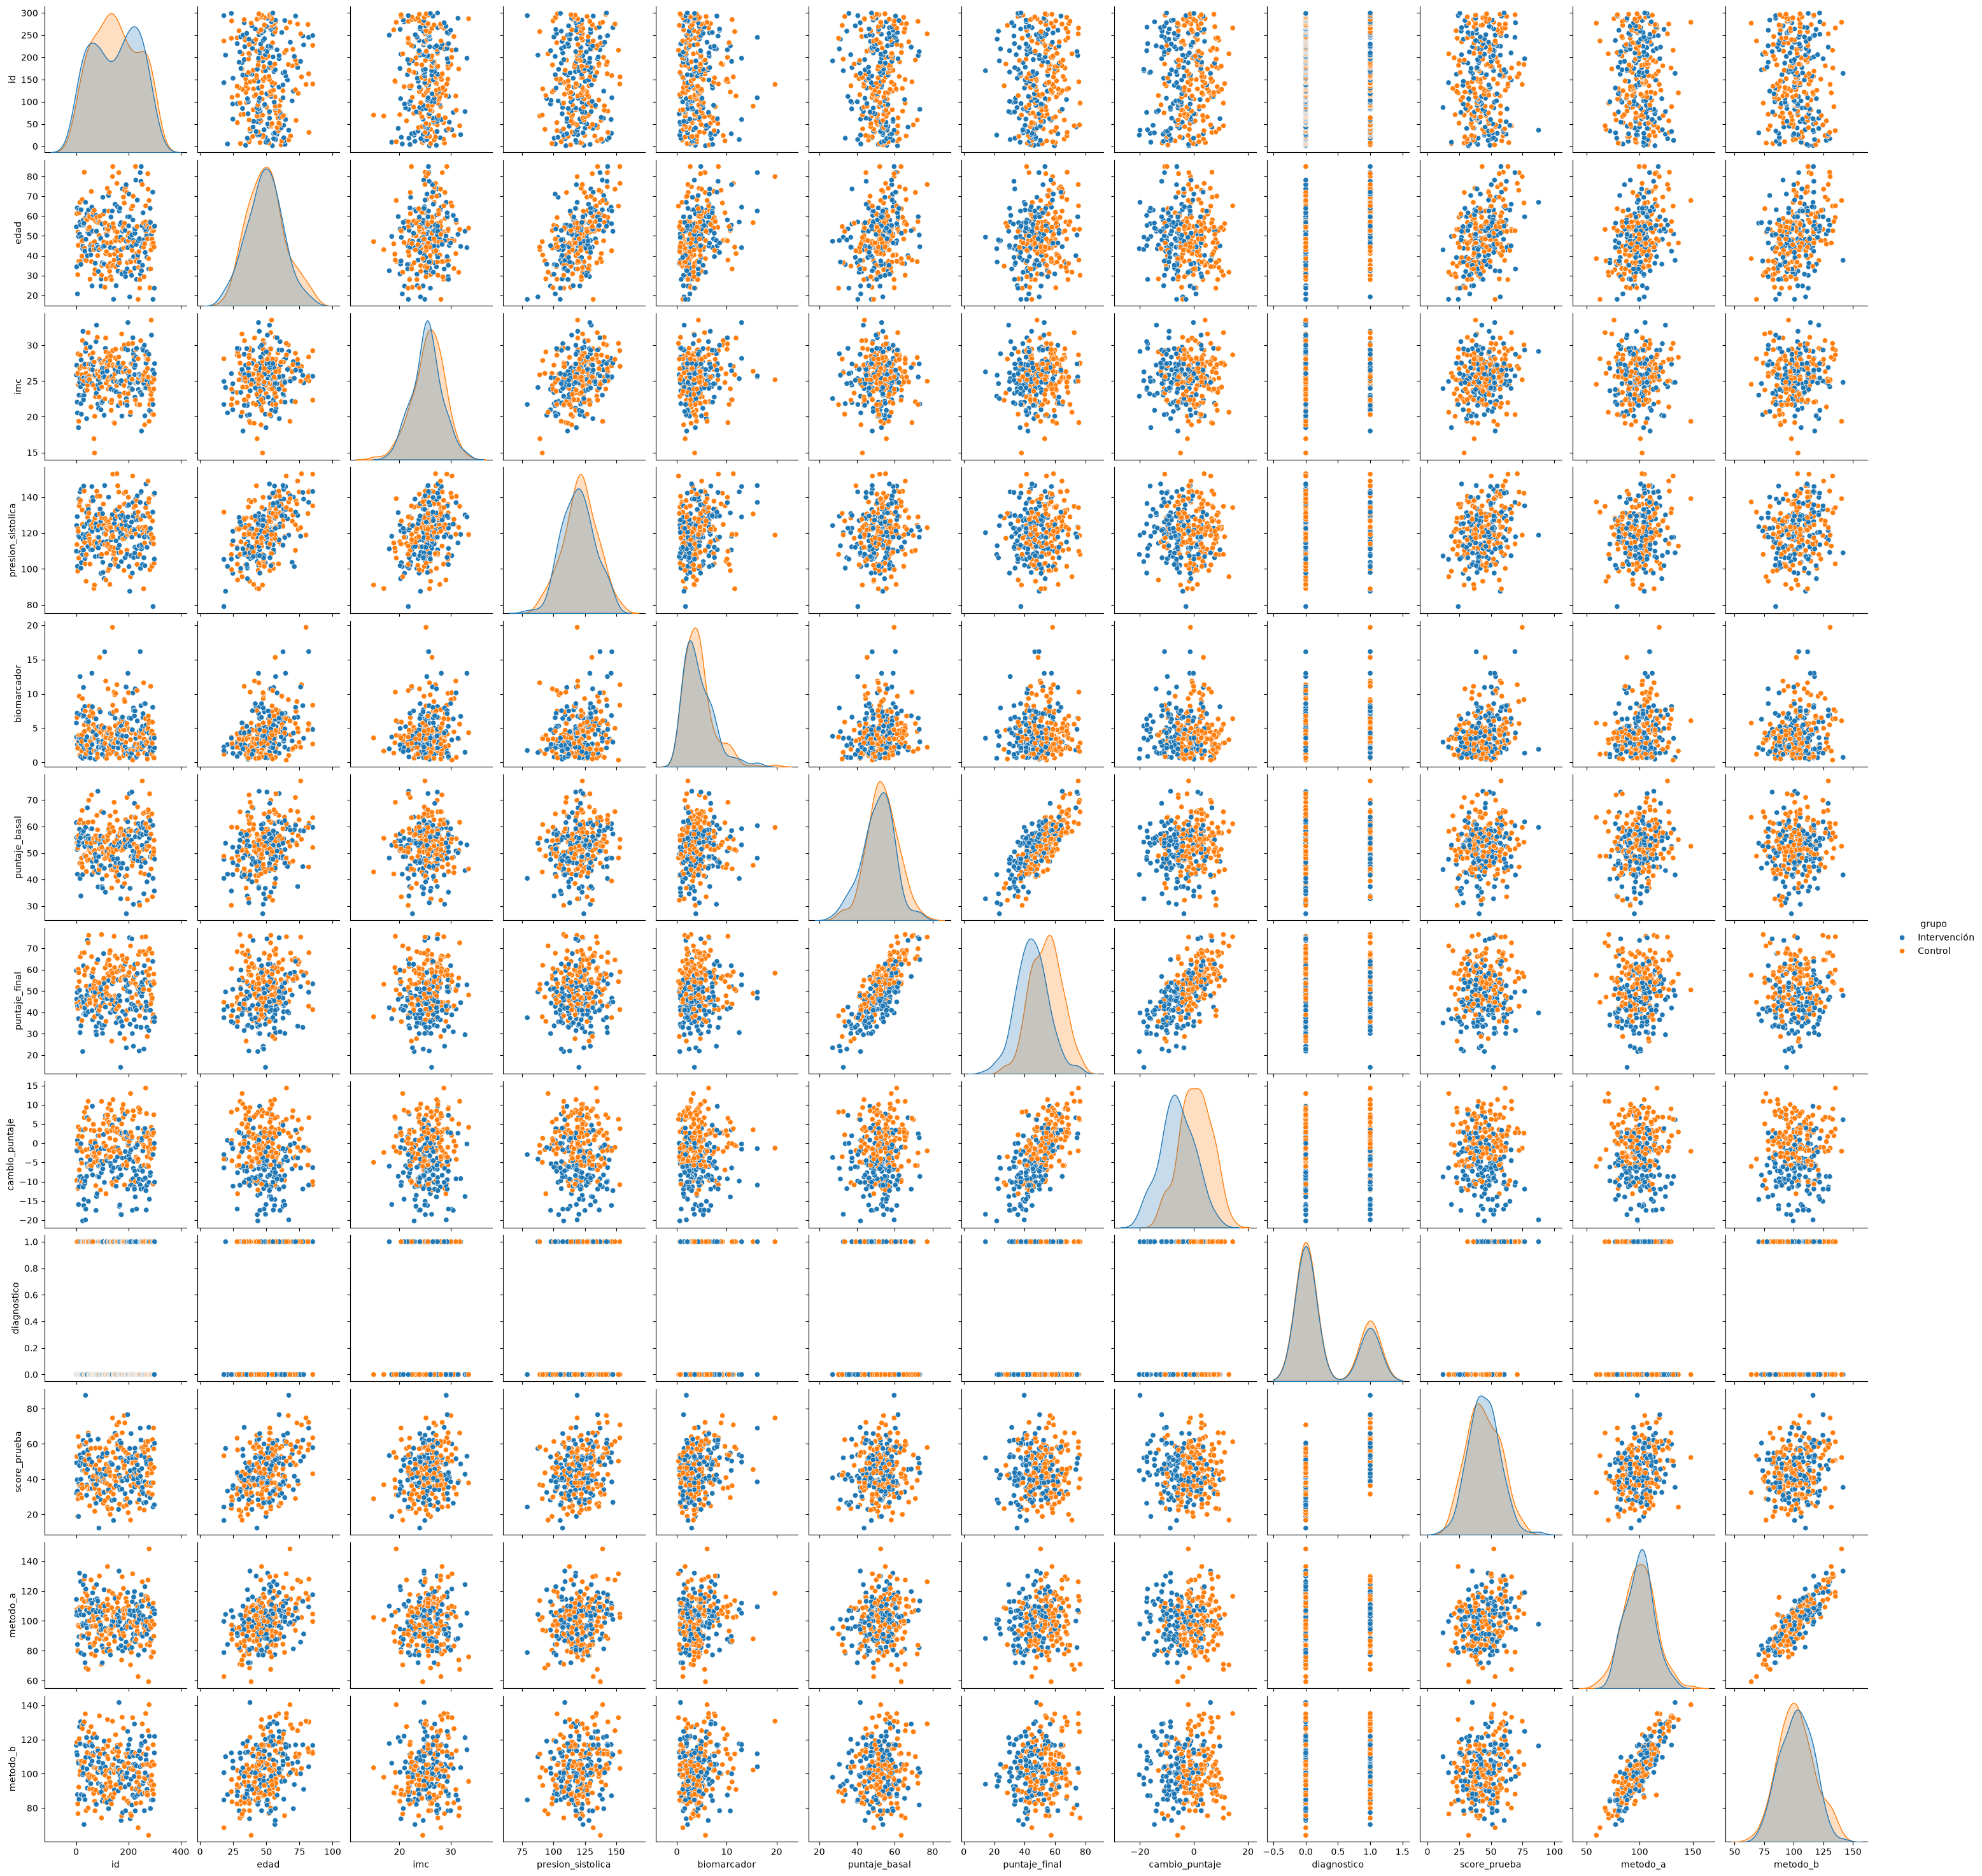

In [5]:
import seaborn as sns
sns.pairplot(df, hue='grupo')